In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

data_dir = 'data\\train_ro'
val_dir = 'data\\data1'
# Define data transformations
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Load datasets
image_datasets = {
    'train': datasets.ImageFolder(os.path.join(data_dir), data_transforms['train']),
    'val': datasets.ImageFolder(os.path.join(val_dir), data_transforms['val'])
}
dataloaders = {x: DataLoader(
    image_datasets[x],
    batch_size=32,  # 增加批次大小，充分利用 GPU
    shuffle=(x=='train'),
    num_workers=6,  # 根據您的 CPU 核心數調整
    pin_memory=True,  # 加速 CPU->GPU 數據傳輸
    prefetch_factor=2,  # 每個 worker 預加載的批次數
    persistent_workers=True  # 避免每個 epoch 後重啟 workers
) for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

In [3]:
print(len(class_names))

10000


In [4]:
import torchvision.models as models
import torch.nn as nn
import torch

# Squeeze-and-Excitation (SE) Block
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

# --- 若要用CBAM，請改用下方這個block，並將SimpleCNN裡SEBlock換成CBAMBlock ---
# class CBAMBlock(nn.Module):
#     def __init__(self, channel, reduction=16, kernel_size=7):
#         super(CBAMBlock, self).__init__()
#         self.avg_pool = nn.AdaptiveAvgPool2d(1)
#         self.max_pool = nn.AdaptiveMaxPool2d(1)
#         self.fc = nn.Sequential(
#             nn.Linear(channel, channel // reduction, bias=False),
#             nn.ReLU(inplace=True),
#             nn.Linear(channel // reduction, channel, bias=False)
#         )
#         self.sigmoid_channel = nn.Sigmoid()
#         self.conv_spatial = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
#         self.sigmoid_spatial = nn.Sigmoid()
#     def forward(self, x):
#         b, c, h, w = x.size()
#         avg = self.fc(self.avg_pool(x).view(b, c))
#         max = self.fc(self.max_pool(x).view(b, c))
#         attn = self.sigmoid_channel(avg + max).view(b, c, 1, 1)
#         x = x * attn.expand_as(x)
#         avg_out = torch.mean(x, dim=1, keepdim=True)
#         max_out, _ = torch.max(x, dim=1, keepdim=True)
#         spatial = torch.cat([avg_out, max_out], dim=1)
#         spatial_attn = self.sigmoid_spatial(self.conv_spatial(spatial))
#         x = x * spatial_attn.expand_as(x)
#         return x

# 定義有SE注意力的CNN
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            SEBlock(32),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            SEBlock(64),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            SEBlock(128),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            SEBlock(256),
            nn.MaxPool2d(2, 2),

            nn.AdaptiveAvgPool2d((1, 1))
        )
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return x

# 自定義分類模型（無Dropout）
class CustomCNNModel(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNNModel, self).__init__()
        self.features = SimpleCNN()
        self.classifier = nn.Sequential(
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# 宣告模型
model = CustomCNNModel(len(class_names))

# 印出模型架構
print(model)

CustomCNNModel(
  (features): SimpleCNN(
    (features): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): SEBlock(
        (avg_pool): AdaptiveAvgPool2d(output_size=1)
        (fc): Sequential(
          (0): Linear(in_features=32, out_features=2, bias=False)
          (1): ReLU(inplace=True)
          (2): Linear(in_features=2, out_features=32, bias=False)
          (3): Sigmoid()
        )
      )
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU(inplace=True)
      (7): SEBlock(
        (avg_pool): AdaptiveAvgPool2d(output_size=1)
        (fc): Sequential(
          (0): Linear(in_features=64, out_features=4, bias=False)
          (1): ReLU(inplace=True)
          (2): Linear(in_feat

First, let's print the model architecture to understand its structure:

Run the above code to see the structure of the model. Look for the final layer that produces the class scores, typically named something like classifier, head, or fc.


From the model architecture, it looks like the final classification layer is named classifier. 

To modify this layer for your custom classification task, you should replace the classifier layer with a new Linear layer that has the appropriate number of output classes for your dataset.

In [5]:
# Move the model to GPU if available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [6]:
import torch.optim as optim
from torch.optim import lr_scheduler

# Define loss function
criterion = torch.nn.CrossEntropyLoss()

# Define optimizer
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# Learning rate scheduler
exp_lr_scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)


In [7]:
import time
import copy
report_train_acc = []
report_val_acc = []
report_train_loss = []
report_val_loss = []
num_epochs = 50
def train_model(model, criterion, optimizer, scheduler, num_epochs):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            if phase == 'train':
                report_train_acc.append(epoch_acc)
                report_train_loss.append(epoch_loss)
            else:
                report_val_acc.append(epoch_acc)
                report_val_loss.append(epoch_loss)
            # Deep copy the model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model

# Train the model
model = train_model(model, criterion, optimizer, exp_lr_scheduler, num_epochs)

# Save the model
torch.save(model.state_dict(), 'custom_eff.pth')

Epoch 0/49
----------
train Loss: 9.2371 Acc: 0.0000
val Loss: 9.0451 Acc: 0.0002

Epoch 1/49
----------
train Loss: 8.8107 Acc: 0.0002
val Loss: 8.1752 Acc: 0.0012

Epoch 2/49
----------


KeyboardInterrupt: 

# Testing

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os
import time
from tqdm import tqdm  # 添加進度條顯示
# 初始化模型架構
model = models.efficientnet_b0(pretrained=False)
# 修改分類器層以符合您的類別數量
num_ftrs = model.classifier[1].in_features
model.classifier[1] = torch.nn.Linear(num_ftrs, len(class_names))

# 載入預訓練權重
model_path = "unpre_eff_10k.pth"  # 確保檔案路徑正確
model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))

# 設置為評估模式
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

# 定義測試數據轉換 
test_transform = transforms.Compose([  
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.RandomRotation([-360, 360]),  # 隨機旋轉範圍從 -360 度到 +360 
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    
])

# 載入測試數據集
test_dataset = datasets.ImageFolder('data\\data1', test_transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4)

# 使用動態類別數量
num_classes = len(test_dataset.classes)
class_correct = [0] * num_classes
class_total = [0] * num_classes
class_predictions = [0] * num_classes
total_correct = 0
total_samples = 0


# 計算開始時間
start_time = time.time()

# 使用進度條跟踪測試進度
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="測試進度"):
        inputs, labels = inputs.to(device), labels.to(device)
        
        # 模型預測
        outputs = model(inputs)
        _, predictions = torch.max(outputs, 1)
        
        # 統計整體正確數
        correct = (predictions == labels).sum().item()
        total_correct += correct
        total_samples += labels.size(0)
        
        # 統計每個類別的正確數和總數
        for i in range(len(labels)):
            label = labels[i].item()
            prediction = predictions[i].item()
            class_total[label] += 1
            if label == prediction:
                class_correct[label] += 1
            
            # 統計每個類別被預測的次數
            class_predictions[prediction] += 1

# 計算測試時間
test_time = time.time() - start_time

# 輸出總體準確率
overall_accuracy = 100 * total_correct / total_samples
print(f'總體準確率: {overall_accuracy:.2f}% ({total_correct}/{total_samples})')
print(f'測試完成，耗時: {test_time:.2f} 秒')

# 輸出每個類別的準確率
print("\n各類別準確率:")
for i in range(len(class_names)):
    if class_total[i] > 0:
        accuracy = 100 * class_correct[i] / class_total[i]
        print(f'類別 {i}: {accuracy:.2f}% ({class_correct[i]}/{class_total[i]})')

# 輸出每個類別被預測到的次數
print("\n各類別被預測次數:")
for i in range(len(class_names)):
    print(f'類別 {i}: {class_predictions[i]}')

測試進度: 100%|██████████| 157/157 [00:27<00:00,  5.65it/s]

總體準確率: 0.33% (33/10000)
測試完成，耗時: 27.78 秒

各類別準確率:
類別 0: 0.00% (0/1)
類別 1: 0.00% (0/1)
類別 2: 0.00% (0/1)
類別 3: 0.00% (0/1)
類別 4: 0.00% (0/1)
類別 5: 0.00% (0/1)
類別 6: 0.00% (0/1)
類別 7: 0.00% (0/1)
類別 8: 0.00% (0/1)
類別 9: 0.00% (0/1)
類別 10: 0.00% (0/1)
類別 11: 0.00% (0/1)
類別 12: 0.00% (0/1)
類別 13: 0.00% (0/1)
類別 14: 0.00% (0/1)
類別 15: 0.00% (0/1)
類別 16: 0.00% (0/1)
類別 17: 0.00% (0/1)
類別 18: 0.00% (0/1)
類別 19: 0.00% (0/1)
類別 20: 0.00% (0/1)
類別 21: 0.00% (0/1)
類別 22: 0.00% (0/1)
類別 23: 0.00% (0/1)
類別 24: 0.00% (0/1)
類別 25: 0.00% (0/1)
類別 26: 0.00% (0/1)
類別 27: 0.00% (0/1)
類別 28: 0.00% (0/1)
類別 29: 0.00% (0/1)
類別 30: 0.00% (0/1)
類別 31: 0.00% (0/1)
類別 32: 0.00% (0/1)
類別 33: 0.00% (0/1)
類別 34: 0.00% (0/1)
類別 35: 0.00% (0/1)
類別 36: 0.00% (0/1)
類別 37: 0.00% (0/1)
類別 38: 0.00% (0/1)
類別 39: 0.00% (0/1)
類別 40: 0.00% (0/1)
類別 41: 0.00% (0/1)
類別 42: 0.00% (0/1)
類別 43: 0.00% (0/1)
類別 44: 0.00% (0/1)
類別 45: 0.00% (0/1)
類別 46: 0.00% (0/1)
類別 47: 0.00% (0/1)
類別 48: 0.00% (0/1)
類別 49: 0.00% (0/1)
類別 50: 0.0

[0.000e+00 0.000e+00 0.000e+00 1.000e-04 0.000e+00 2.000e-04 7.000e-04
 8.000e-04 2.900e-03 1.050e-02 1.850e-02 1.320e-02 7.200e-03 2.600e-03
 1.400e-03 2.000e-03 2.100e-03 1.700e-03 2.900e-03 6.100e-03 8.000e-03
 1.760e-02 3.200e-02 7.260e-02 1.485e-01 2.841e-01 4.801e-01 6.850e-01
 8.231e-01 8.766e-01 9.027e-01 8.916e-01 8.540e-01 7.806e-01 6.933e-01
 6.032e-01 5.284e-01 5.168e-01 5.513e-01 6.226e-01 7.010e-01 7.979e-01
 8.945e-01 9.509e-01 9.779e-01 9.919e-01 9.969e-01 9.995e-01 9.998e-01
 9.999e-01]
[9.31099259 9.23119178 9.17421742 9.01482449 8.66692631 8.17645003
 7.59141666 7.0089101  6.46547563 6.07931057 5.95054512 6.00824133
 6.16088763 6.31642436 6.38863342 6.40319756 6.3392588  6.1723058
 5.89233938 5.53054976 5.13106853 4.67196695 4.17823352 3.62887941
 3.02564194 2.40126664 1.7847521  1.28140666 0.96351445 0.81670772
 0.7611166  0.77967854 0.85715586 0.96931421 1.10592942 1.29044398
 1.49774803 1.5406247  1.4478679  1.2293943  0.97470264 0.69862446
 0.39474101 0.21114601 

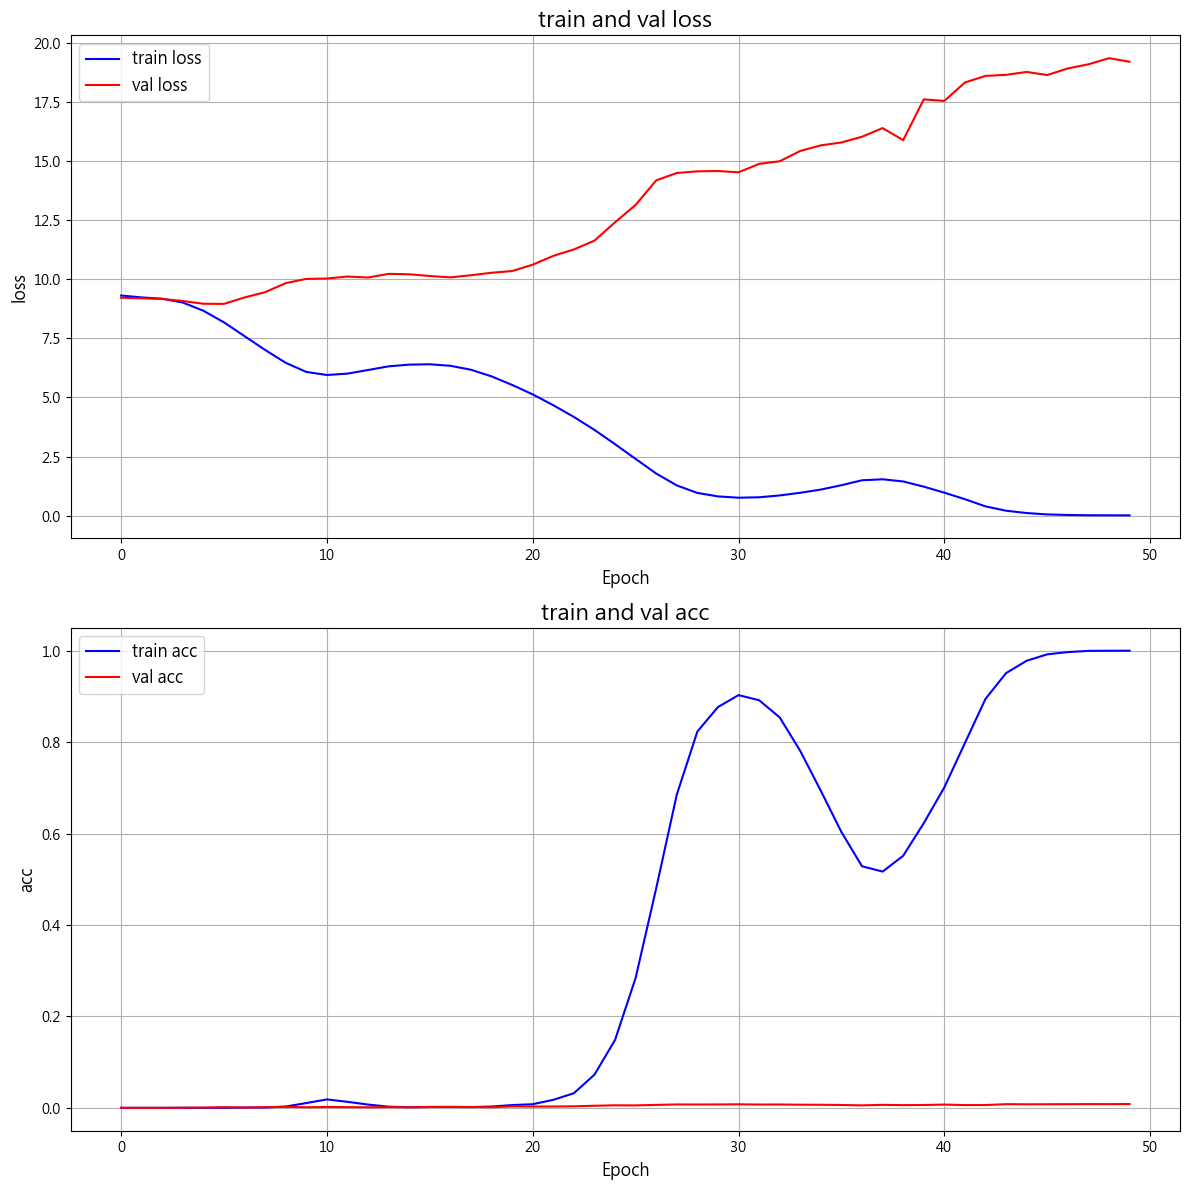

最終訓練損失: 0.0149, 最終訓練準確率: 0.9999
最終驗證損失: 19.1967, 最終驗證準確率: 0.0084


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

train_loss = report_train_loss

# 訓練準確率
train_acc = report_train_acc

val_acc = report_val_acc
# 驗證損失
val_loss = report_val_loss
# 從訓練記錄中提取數據
epochs = list(range(50))

train_acc = np.array([acc.cpu().numpy() if torch.is_tensor(acc) else acc for acc in train_acc])
train_loss = np.array([loss if isinstance(loss, float) else loss.cpu().item() for loss in train_loss])
val_acc = np.array([acc.cpu().numpy() if torch.is_tensor(acc) else acc for acc in val_acc])
val_loss = np.array([loss if isinstance(loss, float) else loss.cpu().item() for loss in val_loss])
print(train_acc)
print(train_loss)
print(val_acc)
print(val_loss)
# 設置中文字體
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

# 創建包含兩個子圖的圖表
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# 繪製損失曲線
ax1.plot(epochs, train_loss, 'b-', label='train loss')
ax1.plot(epochs, val_loss, 'r-', label='val loss')
ax1.set_title('train and val loss', fontsize=16)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('loss', fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(True)
ax1.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))

# 繪製準確率曲線
ax2.plot(epochs, train_acc, 'b-', label='train acc')
ax2.plot(epochs, val_acc, 'r-', label='val acc')
ax2.set_title('train and val acc', fontsize=16)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('acc', fontsize=12)
ax2.legend(fontsize=12)
ax2.grid(True)
ax2.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))

# 顯示圖表
plt.tight_layout()
plt.show()

# 擷取關鍵統計資訊
print(f"最終訓練損失: {train_loss[-1]:.4f}, 最終訓練準確率: {train_acc[-1]:.4f}")
print(f"最終驗證損失: {val_loss[-1]:.4f}, 最終驗證準確率: {val_acc[-1]:.4f}")

In [ ]:
import torch
import torchvision.models as models
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt



# 初始化模型架構
model = models.efficientnet_b0(pretrained=False)
# 修改分類器層以符合您的類別數量
num_ftrs = model.classifier[1].in_features
model.classifier[1] = torch.nn.Linear(num_ftrs, len(class_names))

# 載入預訓練權重
model_path = "efficientnet_b0_custom_model.pth"  # 確保檔案路徑正確
model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))

# 設置為評估模式
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

# 影像預處理函數
def process_single_image(image_path):
    image = Image.open(image_path)
    # 使用與訓練時相同的轉換
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    # 轉換圖片
    image_tensor = transform(image)
    # 添加batch維度
    image_tensor = image_tensor.unsqueeze(0)
    return image_tensor, image

# 預測單張圖片
def predict_image(image_path):
    # 載入和處理圖片
    image_tensor, original_image = process_single_image(image_path)
    image_tensor = image_tensor.to(device)
    
    # 進行預測
    with torch.no_grad():
        outputs = model(image_tensor)
        _, predicted = torch.max(outputs, 1)
        print(torch.max(outputs, 1))
        predicted_class = predicted.item()
    
    # 計算預測機率
    probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
    confidence = probabilities[predicted_class].item()
    
    # 返回結果
    return predicted_class, confidence, original_image

# 使用範例
if __name__ == "__main__":
    # 設定圖片路徑
    test_image_path = "111.png"  # 替換成您要測試的圖片
    
    # 進行預測
    predicted_class, confidence, image = predict_image(test_image_path)
    
    # 顯示結果
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.title(f'預測類別: {class_names[predicted_class]} (信心度: {confidence:.2%})')
    plt.axis('off')
    plt.show()
    
    print(f"\n預測類別: {class_names[predicted_class]}")
    print(f"預測機率: {confidence:.2%}")

c:\Users\User\anaconda3\envs\fastervit\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\User\anaconda3\envs\fastervit\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


FileNotFoundError: [Errno 2] No such file or directory: 'efficientnet_b0_custom_model.pth'